In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import dash
from dash import Dash, html, dash_table, dcc
from dash.dependencies import Input, Output
import dash_bootstrap_components as dbc

# Mini-Lab: A Simple Dash app

In this assignment, you will create a couple Dash apps to visualize how home prices are influence by many possible relevant variables.

In [73]:
ames = pd.read_csv("https://raw.githubusercontent.com/UOdsci/DSCI_Data_Viz/refs/heads/main/data/ame.csv")
ames.head()

,rownames,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,...,Fence,Misc_Feature,Misc_Val,Mo_Sold,Year_Sold,Sale_Type,Sale_Condition,Sale_Price,Longitude,Latitude
0,1,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,141,31770,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,...,No_Fence,NaN,0,5,2010,WD,Normal,215000,-93.619754,42.054035
1,2,One_Story_1946_and_Newer_All_Styles,Residential_High_Density,80,11622,Pave,No_Alley_Access,Regular,Lvl,AllPub,...,Minimum_Privacy,NaN,0,6,2010,WD,Normal,105000,-93.619756,42.053014
2,3,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,81,14267,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,...,No_Fence,Gar2,12500,6,2010,WD,Normal,172000,-93.619387,42.052659
3,4,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,93,11160,Pave,No_Alley_Access,Regular,Lvl,AllPub,...,No_Fence,NaN,0,4,2010,WD,Normal,244000,-93.617320,42.051245
4,5,Two_Story_1946_and_Newer,Residential_Low_Density,74,13830,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,...,Minimum_Privacy,NaN,0,3,2010,WD,Normal,189900,-93.638933,42.060899


In [74]:
ames.columns

Index(['rownames', 'MS_SubClass', 'MS_Zoning', 'Lot_Frontage', 'Lot_Area',
       'Street', 'Alley', 'Lot_Shape', 'Land_Contour', 'Utilities',
       'Lot_Config', 'Land_Slope', 'Neighborhood', 'Condition_1',
       'Condition_2', 'Bldg_Type', 'House_Style', 'Overall_Cond', 'Year_Built',
       'Year_Remod_Add', 'Roof_Style', 'Roof_Matl', 'Exterior_1st',
       'Exterior_2nd', 'Mas_Vnr_Type', 'Mas_Vnr_Area', 'Exter_Cond',
       'Foundation', 'Bsmt_Cond', 'Bsmt_Exposure', 'BsmtFin_Type_1',
       'BsmtFin_SF_1', 'BsmtFin_Type_2', 'BsmtFin_SF_2', 'Bsmt_Unf_SF',
       'Total_Bsmt_SF', 'Heating', 'Heating_QC', 'Central_Air', 'Electrical',
       'First_Flr_SF', 'Second_Flr_SF', 'Gr_Liv_Area', 'Bsmt_Full_Bath',
       'Bsmt_Half_Bath', 'Full_Bath', 'Half_Bath', 'Bedroom_AbvGr',
       'Kitchen_AbvGr', 'TotRms_AbvGrd', 'Functional', 'Fireplaces',
       'Garage_Type', 'Garage_Finish', 'Garage_Cars', 'Garage_Area',
       'Garage_Cond', 'Paved_Drive', 'Wood_Deck_SF', 'Open_Porch_SF',
      

#### Part 1: 2D Plotly plot

In this first part, plot "Sale_Price" (y) as function of "Gr_Liv_Area" (x) i.e. usable square footage. Change the color of points based on "Year_Built". You should assign the graph to an object called "fig".

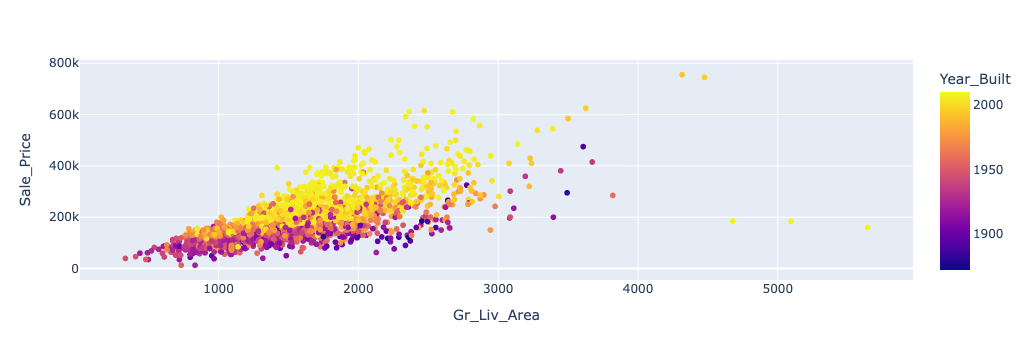

In [75]:
fig = px.scatter(ames, x = 'Gr_Liv_Area', y = 'Sale_Price', color = 'Year_Built')
fig

Now, create a Dash app that plots the 2d image you just made with [dcc.Graph](https://dash.plotly.com/dash-core-components/graph). Don't add any interactive components yet. I've included the skeleton for the app below.

In [76]:
app = dash.Dash(__name__)

app.layout = html.Div([
    # Scatterplot
    html.H1('Different home prices'),
    dcc.Graph(figure = fig)
])

# def home(variable):
#     fig = px.line(ames, x = 'Gr_Liv_Area', y = 'Sale_Price', color = 'Year_Built')

#     return fig

    
if __name__ == '__main__':
    app.run(debug=True, port = '8052')

We'll now create an interactive app that lets the user change the color of the points based on some third covariate. First, create an object called "covariates" that contains all of the column names from `ames` except "rownames".

In [77]:
NoRow = ames.drop(columns = ['rownames'])
                  
covariates = NoRow.columns
covariates

Index(['MS_SubClass', 'MS_Zoning', 'Lot_Frontage', 'Lot_Area', 'Street',
       'Alley', 'Lot_Shape', 'Land_Contour', 'Utilities', 'Lot_Config',
       'Land_Slope', 'Neighborhood', 'Condition_1', 'Condition_2', 'Bldg_Type',
       'House_Style', 'Overall_Cond', 'Year_Built', 'Year_Remod_Add',
       'Roof_Style', 'Roof_Matl', 'Exterior_1st', 'Exterior_2nd',
       'Mas_Vnr_Type', 'Mas_Vnr_Area', 'Exter_Cond', 'Foundation', 'Bsmt_Cond',
       'Bsmt_Exposure', 'BsmtFin_Type_1', 'BsmtFin_SF_1', 'BsmtFin_Type_2',
       'BsmtFin_SF_2', 'Bsmt_Unf_SF', 'Total_Bsmt_SF', 'Heating', 'Heating_QC',
       'Central_Air', 'Electrical', 'First_Flr_SF', 'Second_Flr_SF',
       'Gr_Liv_Area', 'Bsmt_Full_Bath', 'Bsmt_Half_Bath', 'Full_Bath',
       'Half_Bath', 'Bedroom_AbvGr', 'Kitchen_AbvGr', 'TotRms_AbvGrd',
       'Functional', 'Fireplaces', 'Garage_Type', 'Garage_Finish',
       'Garage_Cars', 'Garage_Area', 'Garage_Cond', 'Paved_Drive',
       'Wood_Deck_SF', 'Open_Porch_SF', 'Enclosed_Porch', 

Now add a dropdown menu using [dcc.Dropdown](https://dash.plotly.com/dash-core-components/dropdown) with your covariates as options. You still don't need to update your figure based the options yet; just get the menu added.

In [78]:
app = dash.Dash(__name__)

app.layout = html.Div([
    
    # Dropdown menu
    dcc.Dropdown(
        id = 'Column Select',
        options = covariates,
        value = 'MS_Subclass',
        clearable = False
    ),

    # Scatterplot
    dcc.Graph(id = 'scatter', figure = fig)
])

if __name__ == '__main__':
    app.run(debug=True, port = '8052')

Now we'll update the figure based on the dropdown menu input. This will require a few changes:

First, we'll replace the figure in `dcc.Graph` with an "id". We'll reference this id when defining the output of the dashboard.

Second, we'll need a [@app.callback()](https://dash.plotly.com/basic-callbacks) function to relate the input from the Dropdown to the Output of our figure. The `Output` should reference the id of your graph. The component property (the second argument) for a Graph should be 'figure'. The `Input()` should reference the id of your Dropdown component, and the component property should be 'value'.

Third, we'll need an update function that takes the value from your `Input` as a variable. This function will return the figure, with color defined by the selected covariate.

In [79]:
app = dash.Dash(__name__)

app.layout = html.Div([
    
    # Dropdown menu
    dcc.Dropdown(
        id = 'Column Select',
        options = covariates,
        # Default Value
        value = 'MS_SubClass',
        clearable = False
    ),

    # Scatterplot
    dcc.Graph(id = 'scatter')
])

@app.callback(
    Output('scatter', 'figure'),
    Input('Column Select', 'value')
)

def update_plot(covariate):
    
    fig = px.scatter(ames, x = 'Gr_Liv_Area', y = 'Sale_Price', color = covariate)
    
    return fig

if __name__ == '__main__':
    app.run(debug=True, port = '8052')

#### Layouts and additional components

There is a significant amount of overplotting going on with our figure and, depending on the covariate and associated point color, the total number of points can be hard to discern. To help, let's add a [dcc.Slider](https://dash.plotly.com/dash-core-components/slider) to adjust the opacity of the graph. The slider should be bounded on 0 to 1, and should input to the `opacity` argument in `px.scatter`). Note that you will need a second `Input` for your slider.

To do this, we're going to change the layout of the dashboard. With `dbc.Container()` (skeleton provided), add two rows. The first one should contain two columns, one with your graph and the other with your dropdown menu. The second row should only contain the slider. Reference [this page](https://dash-bootstrap-components.opensource.faculty.ai/docs/components/layout/) for creating Dash layouts. 

In [80]:
import dash_bootstrap_components as dbc

app = Dash(__name__, external_stylesheets=[dbc.themes.BOOTSTRAP])

app.layout = dbc.Container([
    dbc.Row([
        dbc.Col([
            html.H1('Home Prices by Usable Square Footage'),
            dcc.Graph(id = 'scatter')
        ]),
        dbc.Col([
            dcc.Dropdown(
                id = 'Column Select',
                options = covariates,
                # Default Value
                value = 'MS_SubClass',
                clearable = False
            ),
        ]),
    ]),
    dbc.Row([
        dcc.Slider(0, 1, 0.1,
                   value = 0.5,
                   id = 'opacity'
                  ),
    ]),
])
        
# Callback to update the scatter plot based on the dropdown and slider values
@app.callback(
    Output('scatter', 'figure'),
    Input('Column Select', 'value'),  # Dropdown input
    Input('opacity', 'value')  # Slider input
)

def update_plot(covariate, opacity):
    
    fig = px.scatter(ames, x = 'Gr_Liv_Area', y = 'Sale_Price', color = covariate, width = 1200, height = 700)
    
    return fig
    

# Run the app
if __name__ == '__main__':
    app.run(debug=True, port = '8052')

---------------------------------------------------------------------------
IndexError                                Traceback (most recent call last)
IndexError: list index out of range

---------------------------------------------------------------------------
IndexError                                Traceback (most recent call last)
IndexError: list index out of range



#### Putting it all together: 3D plot

Now create a 3D scatterplot (`px.scatter_3d`). The z-variable should be fixed as "Sale_Price", but there should be drop-down menus for the x and y variables, as well as a covariate affecting color. Be sure the drop-down menus are labeled and that they are in a separate column than the scatterplot. Include an opacity slider somewhere in your layout. Be sure that there are [html headers](https://dash.plotly.com/dash-html-components) labeling each dropdown menu.

In [108]:
# Your 3D app
import dash_bootstrap_components as dbc

app = Dash(__name__, external_stylesheets=[dbc.themes.BOOTSTRAP])

app.layout = dbc.Container([
    dbc.Row([
        dbc.Col([
            html.H1('Home Prices by Usable Square Footage'),
            dcc.Graph(id = 'scatter')
        ]),
        dbc.Col([
            html.H1('Color Variable'),
            dcc.Dropdown(
                id = 'Column Select',
                options = covariates,
                # Default Value
                value = 'MS_SubClass',
                clearable = False
            ),
            html.H1('X Variable'),
            dcc.Dropdown(
                id = 'x_select',
                options = covariates,
                # Default Value
                value = 'Gr_Liv_Area',
                clearable = False
            ),
            html.H1('Y Variable'),
            dcc.Dropdown(
                id = 'y_select',
                options = covariates,
                # Default Value
                value = 'Sale_Price',
                clearable = False,
            ),
        ]),
    ]),
    dbc.Row([
        dcc.Slider(0, 1, 0.1,
                   value = 0.5,
                   id = 'opacity'
                  ),
    ]),
])
        
# Callback to update the scatter plot based on the dropdown and slider values
@app.callback(
    Output('scatter', 'figure'),
    Input('Column Select', 'value'),  # Dropdown input
    Input('opacity', 'value'), # Slider input
    Input('x_select', 'value'),
    Input('y_select', 'value')
)


def update_plot(covariate, opacity, x_select, y_select):
    
    fig = px.scatter_3d(ames, x = x_select, y = y_select, z = 'Sale_Price', color = covariate, opacity = opacity,
                        width = 900, height = 500)
    
    return fig
    

# Run the app
if __name__ == '__main__':
    app.run(debug=True, port = '8052')

That's it for this lab. You should now be comfortable building simple Dash apps. In the homework assignment next week, you will build your own Dash app with better stylistic elements. Be sure to submit the lab to the relevant assignment on Canvas.